<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/SpamEmail_Dtector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Collection

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [43]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
spam = pd.read_csv("/content/drive/MyDrive/dataset/spam.csv")

In [45]:
spam.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Data Processing

In [46]:
email1 = spam[spam["Category"]==0]
email2 = spam[spam["Category"]==1]

In [47]:
print(email1)

Empty DataFrame
Columns: [Category, Message]
Index: []


In [48]:
print(email2)

Empty DataFrame
Columns: [Category, Message]
Index: []


In [49]:
spam.shape

(5572, 2)

In [50]:
spam.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [51]:
spam.columns = spam.columns.str.strip()

In [52]:
spam.columns = spam.columns.str.lower()

In [53]:
spam.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [54]:
spam.isna().sum()

,0
category,0
message,0


In [55]:
spam[spam.duplicated(subset = ["category", "message"], keep = False)]

,category,message
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...
5535,ham,"I know you are thinkin malaria. But relax, chi..."
5539,ham,Just sleeping..and surfing
5553,ham,Hahaha..use your brain dear


In [56]:
spam.drop_duplicates(subset = ["category", "message"], keep = "first", inplace = True) #dropping duplicates permanently

In [57]:
spam.shape

(5157, 2)

In [58]:
spam.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5157 non-null   object
 1   message   5157 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


In [59]:
spam["category"].value_counts().to_frame()

,count
category,
ham,4516
spam,641


In [60]:
spam.loc[spam["category"] == "spam", "category"] = 1
spam.loc[spam["category"] == "ham", "category"] = 0

In [61]:
spam.head()

,category,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [62]:
spam["category"] = spam["category"].astype("int64")

In [63]:
spam.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5157 non-null   int64 
 1   message   5157 non-null   object
dtypes: int64(1), object(1)
memory usage: 249.9+ KB


### Data Exploration

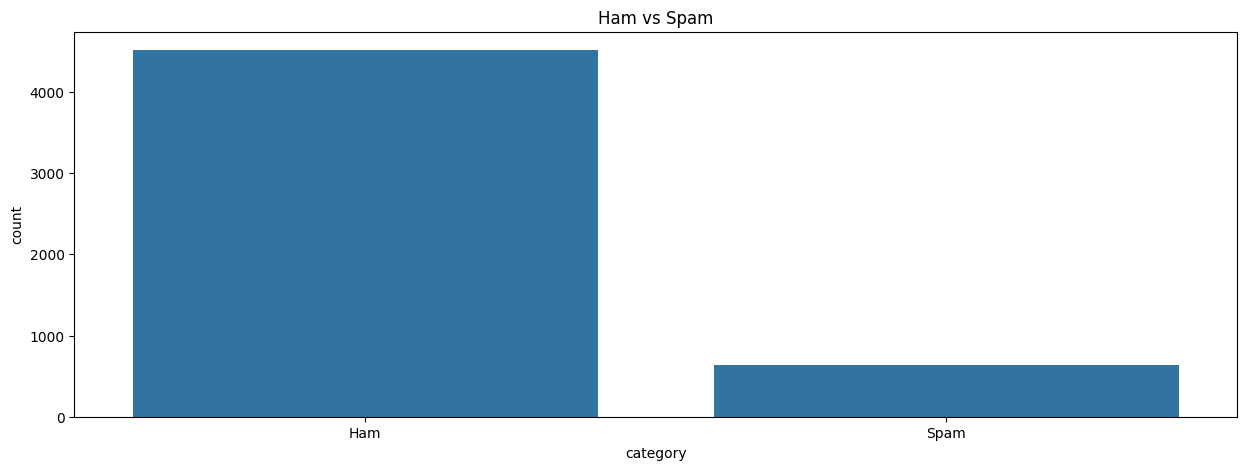

In [68]:
plt.figure(figsize = (15, 5))
sns.countplot(data = spam, x = "category")
plt.title("Ham vs Spam")
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.show()